In [1]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time

from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict

%load_ext autoreload
%autoreload 2

In [5]:
with open("../nets/nets_07022026.pk", "rb") as f:
    net_dict = pk.load(f)


c_base = "C0"
c_goal = "C3"

In [48]:
import datetime as dt
import glob

import dill as pk
from sotodlib import core
from sotodlib.core.metadata.loader import LoaderError
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

In [49]:
result_path = sorted(glob.glob("../abscals/results_*.pk"))[-1]
ufm = "mv24"
band = "090"
ot = ot_from_ufm(ufm)

with open(result_path, "rb") as f:
    result_dict = pk.load(f)
start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 15, tzinfo=dt.timezone.utc)
ctx = core.Context("../ctxs/smurf_det_preproc.yaml")

obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot != ot:
        continue
    if ot in so_nominal_tubes:
        obs_ctx_list.append((obs_id,"../ctxs/preprocess_nominal.yaml"))
    elif ot in aso_tubes:
        obs_ctx_list.append((obs_id, "../ctxs/preprocess_aso.yaml"))
    elif ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../ctxs/preprocess_lf.yaml"))

In [41]:
for (obs_id, ctx_path) in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
metas = []
for (obs_id, ctx_path) in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(obs_id,dets={"dets:stream_id": "ufm_" + str(ufm), "dets:wafer.bandpass": "f" + str(band),},)
            metas.append(meta)
            
        except:
            continue

obs_1780451618_lati3_111
obs_1780451618_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780451618_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780456042_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'l

obs_1780456042_lati3_111
obs_1780458280_lati3_111
obs_1780461905_lati3_111
obs_1780466513_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780466513_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780469103_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'l

obs_1780469103_lati3_111
obs_1780472708_lati3_111
obs_1780476307_lati3_111
obs_1780485790_lati3_111


...

ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1781432140_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1781435359_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'l

obs_1781435359_lati3_111
obs_1781454536_lati3_111
obs_1781457501_lati3_111
obs_1781459628_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1781459628_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1781463232_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'l

obs_1781463232_lati3_111
obs_1781469817_lati3_111
obs_1781473426_lati3_111
obs_1781477033_lati3_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests//det_match/lat_det_match_260416m/assignment_local.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1781477033_lati3_111', 'dets:stream_id': 'ufm_mv24', 'dets:wafer.bandpass': 'f090'}




In [50]:
obs_id, ctx_path = obs_ctx_list[0]
arrays = []
ret_bands = []

raw_cals = []
obs_ids = []
ndets = []
array_nets = []
pwvs = []
els = []
neps = []
phiconvs = []
ctx = core.Context(ctx_path)
try:  # Much faster than ctx.get_meta
    det_info = ctx.get_det_info(obs_id)
except LoaderError:
    print(f"No meta data for obs {obs_id}")


In [56]:
if "mv" in ufm:
    if band == "090":
        ufm_band = 1
    elif band == "150":
        ufm_band = 2
if "uv" in ufm:
    if band == "220":
        ufm_band = 1
    elif band == "280":
        ufm_band = 2
meta = ctx.get_meta(obs_id,dets={"dets:stream_id": "ufm_" + str(ufm), "dets:wafer.bandpass": "f" + str(band),},)

In [62]:
flags = get_det_bias_flags(meta).det_bias_flags
meta.restrict("dets", ~core.flagman.has_any_cuts(flags))
wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

if len(wafer_flag) == 0:
    print(f"No det_info for obs {obs_id}")
bp = (meta.det_cal.bg % 4) // 2

if ufm_band == 1:
    net_flag = wafer_flag * (bp == 0)
elif ufm_band == 2:
    net_flag = wafer_flag * (bp == 1)

raw_cal = np.nanmedian(meta.abscal.raw_abscal_rj[net_flag])
if "noise" in meta.preprocess:
    wnoise = meta.preprocess.noise.white_noise[net_flag]
elif "noiseT" in meta.preprocess:
    wnoise = meta.preprocess.noiseT.white_noise[net_flag]
else:
    print(f"Error: no valid noise ken in {meta.preprocess.keys()}")
ndet = len(np.where(wnoise != 0)[0])

In [86]:
net_mes = wnoise 

In [87]:
clean_nets = []
for net in net_mes:
    if net * 1e6 > 100:
        clean_nets.append(net)

In [88]:
clean_nets = np.array(clean_nets)
array_net = np.nansum((clean_nets * 1e6) ** (-2)) ** (-1 / 2)

In [22]:
import astropy.units as u
from utils.optical_loading import pwv_interp

from latcom.utils import map_utils as mu

pwv = pwv_interp()
labels = []
nets = []
obs = []
pwvs = []
ndets = []
neps = []
neis = []
cals = []
els = []
yields = []
t_obs = []
indv_nets = []
array_freqs = []
arrays = []

ufms = sorted(net_dict.keys())[1:]  # remove index key

freqs = ["030", "040", "090", "150", "220", "280"]

units = r"\mu K_{RJ}"

In [32]:
freq = "090"
if freq in ["030", "040"]:
    flavor = "LF"
    if freq == "030":
        ch = "LF_1"
    else:
        ch = "LF_2"
elif freq in ["090", "150"]:
    flavor = "MF"
    if freq == "090":
        ch = "MF_1"
    else:
        ch = "MF_2"
elif freq in ["220", "280"]:
    flavor = "UHF"
    if freq == "220":
        ch = "UHF_1"
    else:
        ch = "UHF_2"

temp_conv = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor=flavor, ch=ch, kind="baseline"
)

In [33]:
ufm = ufms[8]
for key, sub_dict in net_dict.items():
    if ufm not in key:
        continue
    for sub_key in sub_dict:
        if freq not in sub_key:
            continue
        print(key, sub_key)
        cur_nets = np.array(sub_dict[sub_key]["nets"])
        cur_obs = np.array(sub_dict[sub_key]["obs"])
        cur_ndets = np.array(sub_dict[sub_key]["ndets"])
        cur_abscals = np.array(sub_dict[sub_key]["raw_cal"])
        cur_neis = sub_dict[sub_key]["neps"]
        cur_el = np.array(sub_dict[sub_key]["el"])

        label = str(freq) + "_" + str(ufm)

mv24 090


In [34]:
for j in range(len(cur_nets)):
    cur_time = cur_obs[j].split("_")[1]
    cur_pwv = pwv(cur_time)
    if (
        cur_nets[j] <= 100 and cur_ndets[j] > 100
    ):  # very large nets are not real
        nets.append(cur_nets[j] * temp_conv)
        labels.append(label)
        obs.append(cur_obs[j])
        pwvs.append(cur_pwv)
        ndets.append(cur_ndets[j])
        neps.append(
            cur_nets[j]
            / cur_abscals[j]
            * np.sqrt(2)
            * np.sqrt(cur_ndets[j])
        )
        indv_nets.append(cur_nets[j] * np.sqrt(cur_ndets[j]))
        cals.append(cur_abscals[j])
        els.append(cur_el[j])
        yields.append(cur_ndets[j] / 860)
        t_obs.append(float(cur_time))
        arrays.append(ufm)
        array_freqs.append(freq)
        for nei in cur_neis[j]:
            neis.append(nei)  # noqa : PERF402

In [35]:
labels

['090_mv24']

In [6]:
#df_yield = yd.parse_yield(net_dict=net_dict)
df_yield = parse_dict(net_dict=net_dict)
toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [7]:
#with open("../data/yields.pk", "wb") as f:
#    pk.dump(df_yield, f)

In [35]:
t_cut_low = Time("2026-06-05T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-07-03T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df_yield.labels)
weighted_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 1/np.sin(np.deg2rad(50)))
        & (df_yield.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    weighted_means[i] =np.mean(data)
means_df = pd.DataFrame({"labels": set_labels, "yields": weighted_means})

In [37]:
means_df.loc[means_df.labels == "090_mv24"]

,labels,yields
6,090_mv24,0.829427


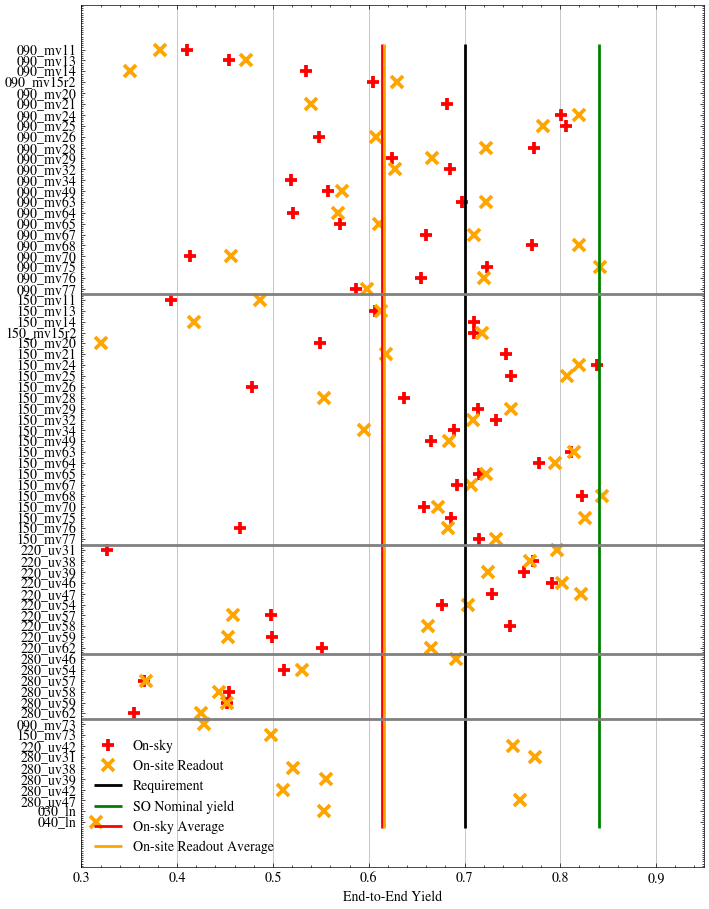

In [31]:


plt.style.use("apj-fullwidth")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 9))

#sns.boxplot(data=df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 3 / np.sin(np.deg2rad(50))),
#    x="yields", y="labels",
#)

sns.pointplot(
    data = means_df,
    x="yields",
    y="labels",
    label="On-sky",
    marker="+",
    linestyle="none",
    color="red"
)


sns.pointplot(
    data=toby_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="x",
    color="orange",
    zorder=2,
    label="On-site Readout",
)
"""
sns.pointplot(
    data=ptown_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="+",
    color="0.05",
    zorder=2,
    label="PTown Dark",
)
"""
plt.xlim(0.3, 0.95)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color="black")
plt.vlines(0.84, ymin=ymin, ymax=ymax, label="SO Nominal yield", color="green")

#plt.vlines(np.nanmean(df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 1 / np.sin(np.deg2rad(50))).yields),
#    ymin=ymin, ymax=ymax, label="On-Sky Average", color="black",
#)
plt.vlines(
    np.nanmean(means_df.yields),
    ymin=ymin, ymax=ymax,
    label="On-sky Average",
    color="red",
)
plt.vlines(
    np.nanmean(toby_df.yields),
    ymin=ymin,
    ymax=ymax,
    label="On-site Readout Average",
    color="orange",
)


pos_090 = len([label for label in set(df_yield.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df_yield.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df_yield.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df_yield.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220, pos_280], xmin=xmin, xmax=xmax, color="0.5")

plt.legend()

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")

plt.savefig("../plts/aso_yield.png", dpi=600, bbox_inches="tight")
plt.savefig("../plts/aso_yield.pdf", dpi=600, bbox_inches="tight")

In [20]:
np.nanmean(df_yield.where(df_yield.labels == "090_mv73").yields)

np.float64(0.3739648326715825)

In [ ]:
total_yield = []
pwvs = []
for time in times:
    ndets = 0
    narrays = 0
    for key in net_dict.keys():
        for sub_key in net_dict[key].keys():
            if freq not in sub_key:
                continue
            cur_obs = np.array(net_dict[key][sub_key]["obs"])
            for j in range(len(cur_obs)):
                if np.isclose(time, float(cur_obs[j].split("_")[1])):
                    cur_ndets = np.array(net_dict[key][sub_key]["ndets"])
                    cur_nets = np.array(net_dict[key][sub_key]["nets"])
                    # if cur_nets[j] <= 100 and cur_ndets[j] > 100: #very large nets are not real
                    ndets += cur_ndets[j]
                    narrays += 860
                    cur_el = np.array(net_dict[key][sub_key]["el"][j])
                    cur_pwv = pwv(cur_obs[j].split("_")[1])
    if narrays == 0:
        continue
    pwvs.append(cur_pwv / np.sin(np.deg2rad(cur_el)))
    total_yield.append(ndets / narrays)

df_total = pd.DataFrame({"yields": total_yield, "pwv": pwvs})